<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/GaussianProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process
## Generate Data

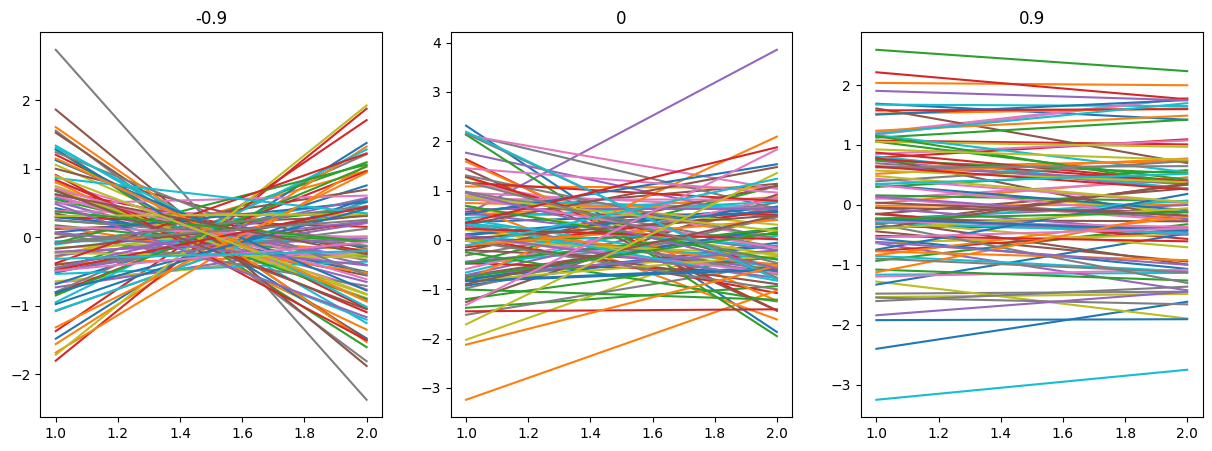

In [123]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100

def data_gen(N, c):

  K = np.array([[1, c],
                [c, 1]])

  y = np.zeros((N, 2))

  for i in range(N):
      y[i] = np.random.multivariate_normal(np.zeros(2), K)

  return y


fig, axis = plt.subplots(1, 3, figsize=(15, 5))

cs = [-0.9, 0, 0.9]
for i in range(len(cs)):
  y = data_gen(N, cs[i])

  for pair in y:
      axis[i].plot([1, 2], pair)
      axis[i].set_title(cs[i])

plt.show()

In [124]:
def covariance_matrix(X, kernel_fun, sigma_d=1.0):
  cvx = np.zeros((len(X), len(X)))
  for i in range(len(X)):
    for j in range(len(X)):
      cvx[i, j] = kernel_fun(X[i], X[j])

  return cvx + 1e-5 * np.eye(len(X)) * sigma_d**2

def k_se(x_m, x_n, sigma=2.0, l=50.0):
  return sigma**2 * np.exp(-(x_m - x_n)**2/2/l**2)

def k_ou(x_m, x_n, sigma=2.0, l=50.0):
  return sigma**2 * np.exp(-np.abs(x_m - x_n)/l)

def k_osc(x_m, x_n, sigma=2.0, l=50.0, A=1.0, P=24.0):
  return sigma**2 * np.exp(-A * np.sin((x_m-x_n)*np.pi/P)**2 - (x_m - x_n)**2/2/l**2)

def k_lin(x_m, x_n, sigma=2.0, c=1.0):
  return sigma**2 * (x_m - c) * (x_n - c)


X = np.linspace(-N/2, N/2, N)

se = covariance_matrix(X, k_se)
ou = covariance_matrix(X, k_ou)
lin = covariance_matrix(X, k_lin)
osc = covariance_matrix(X, k_osc)

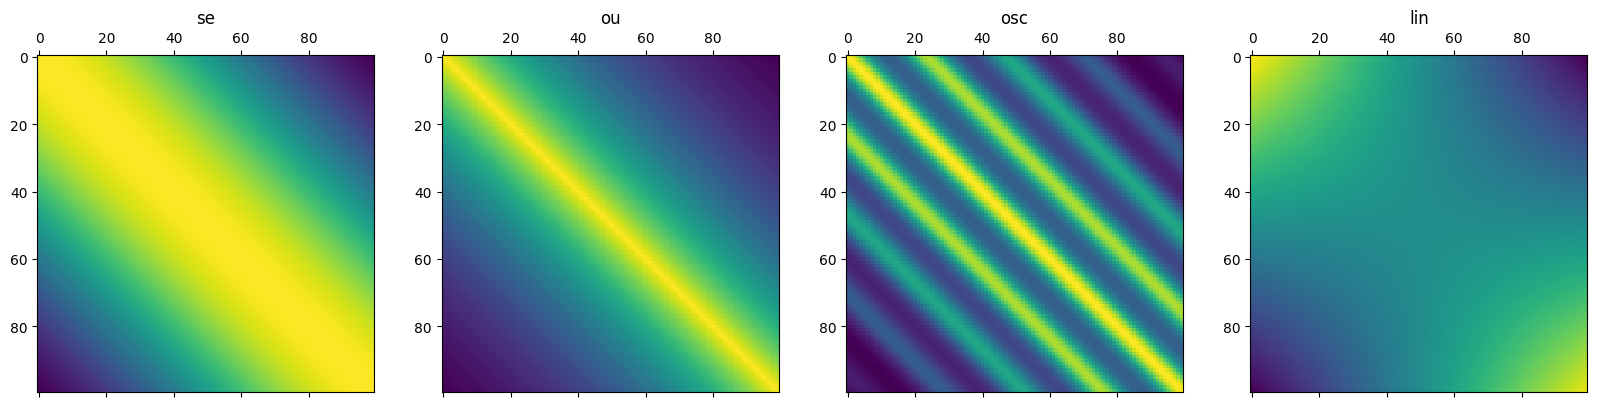

In [125]:
kernels = {'se': se, 'ou': ou, 'osc': osc, 'lin':lin}

fig, axis = plt.subplots(1, 4, figsize=(20,5))
i = 0
for title, kernel in kernels.items():
  axis[i].matshow(kernel)
  axis[i].set_title(title)
  i+=1

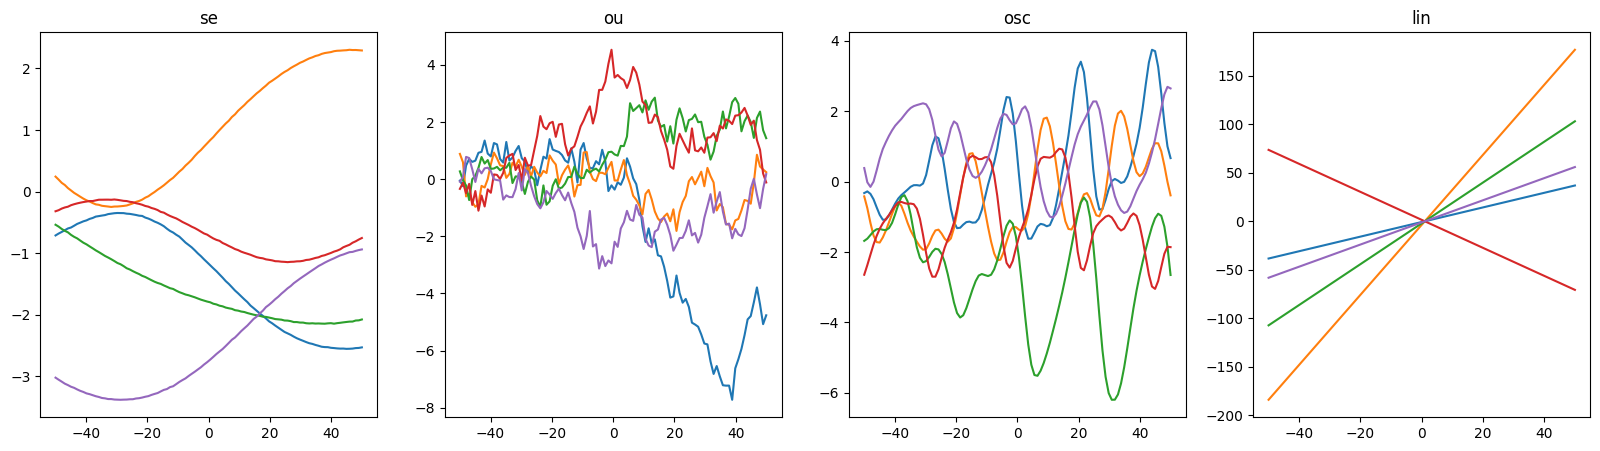

In [126]:

fig, axis = plt.subplots(1, 4, figsize=(20,5))
i = 0
for title, kernel in kernels.items():
  for _ in range(5):
    data_poits = np.random.multivariate_normal(np.zeros(N), kernel)
    axis[i].plot(X, data_poits)
    axis[i].set_title(title)
  i+=1

## Inferring plausible GP priors from samples

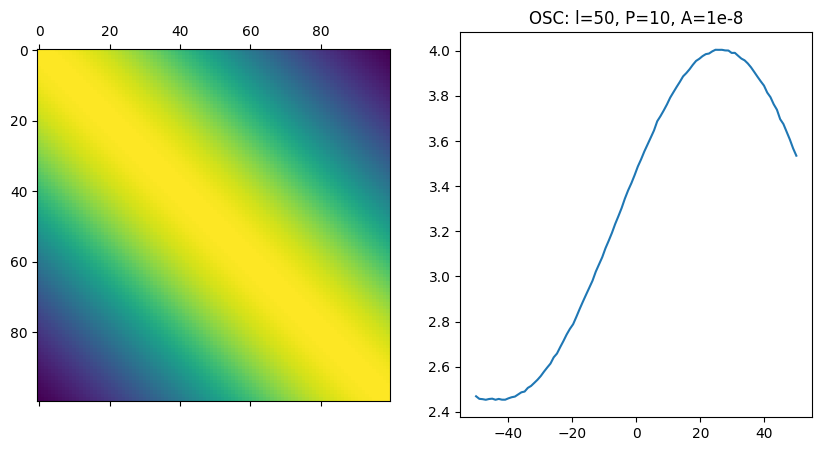

In [127]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

osc_scaled = covariance_matrix(X, lambda x,y: k_osc(x, y, l=50, P=10, A=1e-8))
axis[0].matshow(osc_scaled)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), osc_scaled))
axis[1].set_title("OSC: l=50, P=10, A=1e-8")
plt.show()

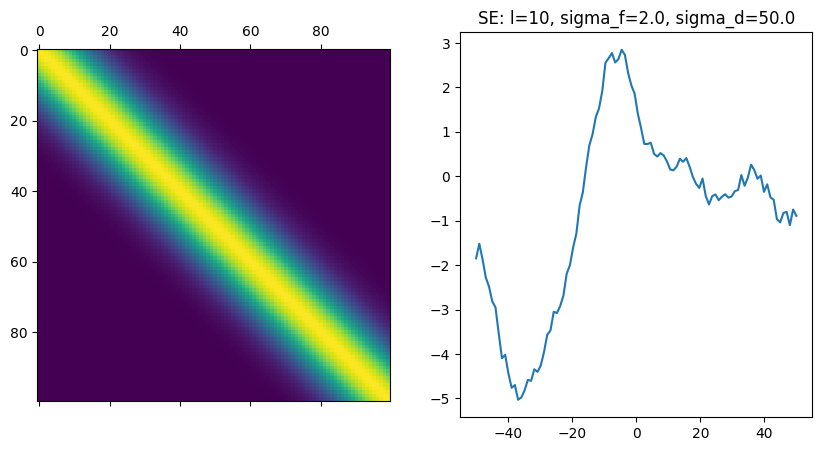

In [128]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled = covariance_matrix(X, lambda x,y: k_se(x, y, l=10, sigma=2), sigma_d=50)
axis[0].matshow(se_scaled)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled))
axis[1].set_title("SE: l=10, sigma_f=2.0, sigma_d=50.0")
plt.show()

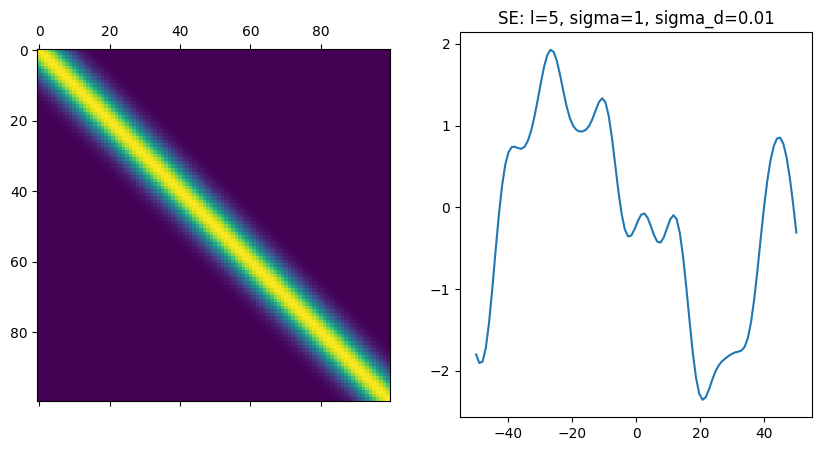

In [129]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled2 = covariance_matrix(X, lambda x,y: k_se(x, y, l=5, sigma=1), sigma_d=0.01)
axis[0].matshow(se_scaled2)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled2))
axis[1].set_title("SE: l=5, sigma=1, sigma_d=0.01")
plt.show()

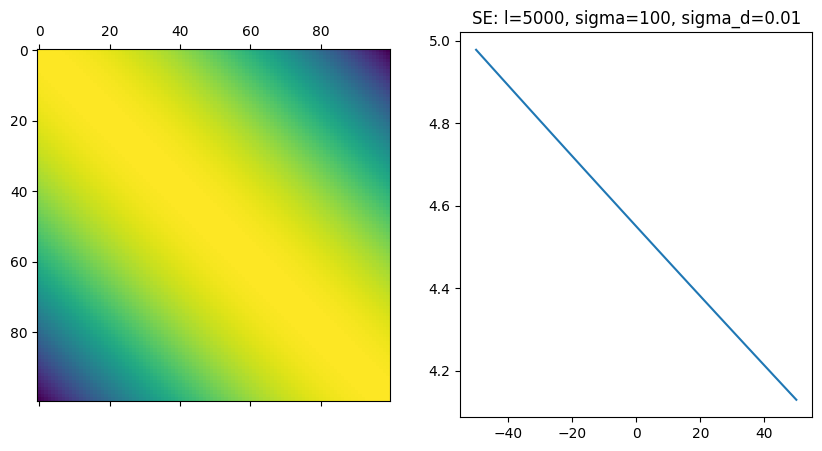

In [130]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled3 = covariance_matrix(X, lambda x,y: k_se(x, y, l=5000, sigma=100), sigma_d=0.01)
axis[0].matshow(se_scaled3)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled3))
axis[1].set_title("SE: l=5000, sigma=100, sigma_d=0.01")
plt.show()

## Kernel intruduce indeuctive bias

osc - NLML:-271.6703, l:47.5523, sigma_f: 1.0228, sigma_d: 0.9127
ou - NLML:-182.8334, l:6810.9580, sigma_f: 2.1519, sigma_d: 0.0010
lin - NLML:71.7561, l:94.1059, sigma_f: 11.4395, sigma_d: 147.2762


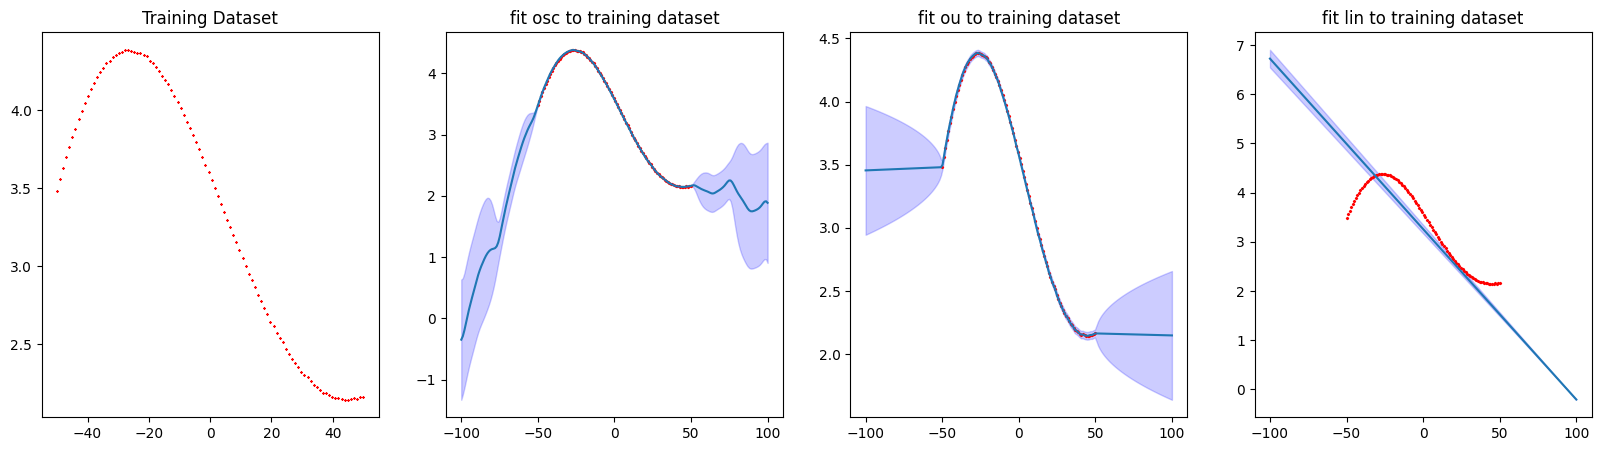

In [131]:
import scipy.optimize as opt

def negative_lml(hyperparameters, X_train, t_train, kernel_func):
  l, sigma_f, sigma_d = hyperparameters

  K_noisy = covariance_matrix(X_train, lambda m, n: kernel_func(m, n, sigma_f, l), sigma_d=sigma_d)

  sign, log_det = np.linalg.slogdet(K_noisy)
  inv_K_times_t = np.linalg.solve(K_noisy, t_train)

  data_fit = 0.5 * np.dot(t_train.T, inv_K_times_t)
  complexity_penalty = 0.5 * log_det
  constant = 0.5 * len(X_train) * np.log(2 * np.pi)

  return data_fit + complexity_penalty + constant

def cross_covariance_matrix(X1, X2, kernel_fun):
  cvx = np.zeros((len(X1), len(X2)))
  for i in range(len(X1)):
    for j in range(len(X2)):
      cvx[i, j] = kernel_fun(X1[i], X2[j])

  return cvx

fig, axis = plt.subplots(1, 4, figsize=(20,5))
t_train = np.random.multivariate_normal(np.zeros(N), kernels['se'])
axis[0].scatter(X, t_train, c='red', s=1, marker='x')
axis[0].set_title("Training Dataset")

X_test = np.linspace(-N, N, 2*N)

i = 0
for title, kernel_fun in {'osc': k_osc, 'ou': k_ou, 'lin': lambda x, y, sigma_f, l: k_lin(x, y, sigma_f, l)}.items():
  initial_guess = [1.0, 1.0, 1.0]
  if title == 'lin':
    bounds = ((None, None), (1e-3, None), (1e-3, None)) # c is free, sigma_f and sigma_d > 0
  else:
    bounds = ((1e-3, None), (1e-3, None), (1e-3, None)) # all must be > 0
  result = opt.minimize(negative_lml, initial_guess, args=(X, t_train, kernel_fun), bounds=bounds)
  l_op, sigma_f_op, sigma_d_op = result.x
  print(f"{title} - NLML:{result.fun:.4f}, l:{l_op:.4f}, sigma_f: {sigma_f_op:.4f}, sigma_d: {sigma_d_op:.4f}")
  learned_kernel = covariance_matrix(X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
  pure_kernel = covariance_matrix(X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=0)

  inv_K_times_t = np.linalg.solve(learned_kernel, t_train)
  K_star_x = cross_covariance_matrix(X_test, X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op))
  mean_test = np.dot(K_star_x, inv_K_times_t)

  K_star_star = covariance_matrix(X_test, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=0)
  inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
  covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
  std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

  axis[i+1].fill_between(X_test, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
  axis[i+1].scatter(X, t_train, c='red', s=2, marker='x')
  axis[i+1].plot(X_test, mean_test)
  axis[i+1].set_title(f"fit {title} to training dataset")
  i+=1

plt.show()
